In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [74]:
# Load the RFM dataset
DATA_DIR = Path("../data")

rfm = pd.read_csv(DATA_DIR / "olist_rfm.csv")

print(rfm.head())
print(rfm.shape)
print(rfm["churn"].value_counts())
print(rfm["churn"].value_counts(normalize=True))


                 customer_unique_id  recency  frequency  monetary  churn
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90      0
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19      0
2  0000f46a3911fa3c0805444483337064      586          1     86.22      1
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62      1
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89      1
(96096, 5)
churn
1    68352
0    27744
Name: count, dtype: int64
churn
1    0.711289
0    0.288711
Name: proportion, dtype: float64


In [75]:

# Define a helper function to train and evaluate model


def run_model(X, y, title):
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Results
    print("="*50)
    print(title)
    print("="*50)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC-ROC: {auc:.4f}")

    # ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Guess"
)

plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title(f"ROC Curve - {title}", fontsize=18)

plt.legend(fontsize=13, loc="best")
plt.grid(True)

plt.show()

Model 1: With Recency (Leakage)
Confusion Matrix:
[[ 5548     1]
 [  105 13566]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5549
           1       1.00      0.99      1.00     13671

    accuracy                           0.99     19220
   macro avg       0.99      1.00      0.99     19220
weighted avg       0.99      0.99      0.99     19220

AUC-ROC: 1.0000


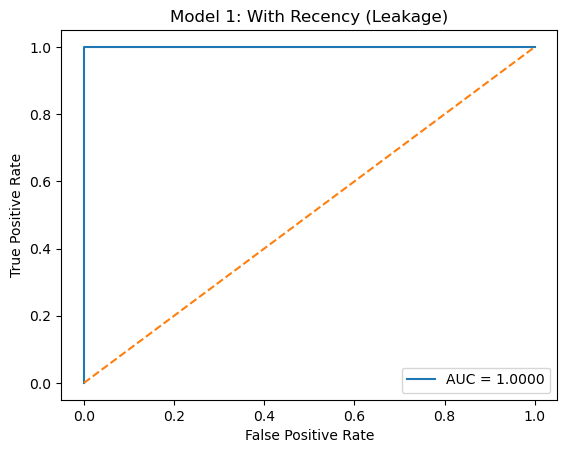

In [76]:

# Model 1: WITH recency (contains leakage)


X1 = rfm[['recency', 'frequency', 'monetary']]
y = rfm['churn']

auc1 = run_model(X1, y, "Model 1: With Recency (Leakage)")


Model 2: Without Recency
Confusion Matrix:
[[  382  5167]
 [  869 12802]]

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.07      0.11      5549
           1       0.71      0.94      0.81     13671

    accuracy                           0.69     19220
   macro avg       0.51      0.50      0.46     19220
weighted avg       0.59      0.69      0.61     19220

AUC-ROC: 0.5102


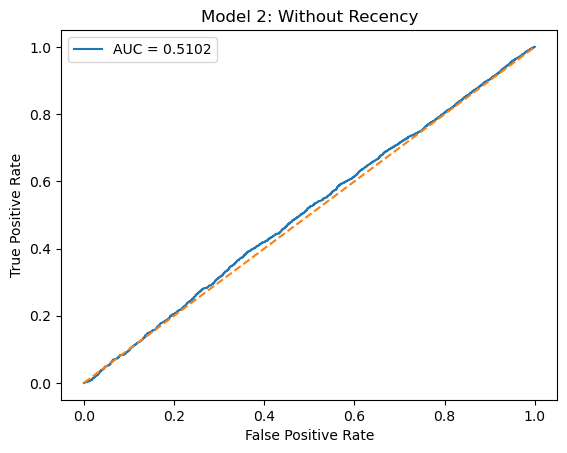

In [77]:

# Model 2: WITHOUT recency (no leakage)


X2 = rfm[['frequency', 'monetary']]

auc2 = run_model(X2, y, "Model 2: Without Recency")